# Real-time Pothole Detection — CS305 Case Design (Colab)

This notebook runs the full gradient-based pothole detection pipeline described in your report,
on your own dataset, and prints every number you need for the yellow highlighted fields:
precision, recall, F1, latency, FPS, and the ablation study table.

**Run the cells in order, top to bottom.** Skip Section 6 (webcam) if you don't need it.

## 1. Setup

In [ ]:
import cv2, numpy as np, os, glob, time, json
import matplotlib.pyplot as plt
print('OpenCV version:', cv2.__version__)

OpenCV version: 4.14.0


## 2. Get your dataset

Pick **one** of the three options below.

**Option A — Upload a zip file** (images + label files) from your computer.

**Option B — Download from Kaggle** (needs your `kaggle.json` API token: Kaggle → Account → Create New API Token).
Two commonly used public datasets:
- `andrewmvd/pothole-detection` (Pascal VOC XML annotations)
- `atulyakumar98/pothole-detection-dataset` (images only — you will need to draw/label boxes yourself, e.g. with [makesense.ai](https://www.makesense.ai/), and export as YOLO .txt)

Check Kaggle for current availability and licence before using either.

**Option C — Mount Google Drive** if your dataset is already there.

After this section you should have:
- `images/`  — folder of road photos (.jpg/.png)
- `labels/`  — one `.txt` (YOLO format: `class cx cy w h`, normalised 0–1) or `.xml` (Pascal VOC) per image, same filename as the image

### Option A — Upload a zip

In [ ]:
from google.colab import files
uploaded = files.upload()   # choose your dataset .zip
import zipfile
zip_name = list(uploaded.keys())[0]
with zipfile.ZipFile(zip_name, 'r') as z:
    z.extractall('dataset')
print('Extracted to ./dataset —  check the folder names below and edit IMAGES_DIR / LABELS_DIR in the next section.')
!find dataset -maxdepth 2 -type d

Saving archive.zip to archive.zip
Extracted to ./dataset —  check the folder names below and edit IMAGES_DIR / LABELS_DIR in the next section.
dataset
dataset/annotations
dataset/images


### Option B — Download from Kaggle

In [ ]:
from google.colab import files
print('Upload your kaggle.json token now:')
uploaded = files.upload()
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!pip install -q kaggle
# Edit the dataset handle below to the one you are using
!kaggle datasets download -d andrewmvd/pothole-detection -p dataset --unzip
!find dataset -maxdepth 2 -type d

Upload your kaggle.json token now:


Saving archive.zip to archive (1).zip
cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/andrewmvd/pothole-detection
License(s): other
100% 334M/334M [00:02<00:00, 145MB/s]

dataset
dataset/annotations
dataset/images


### Option C — Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
# <<< IMPORTANT: Edit this path to where your dataset folder is inside Drive >>>
DRIVE_DATASET_PATH = '/content/drive/MyDrive/pothole_dataset' # Example: '/content/drive/MyDrive/my_pothole_data'
print(f'Set DRIVE_DATASET_PATH to: {DRIVE_DATASET_PATH}')
# You can verify the contents after updating the path, e.g., print('Contents:', os.listdir(DRIVE_DATASET_PATH))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Set DRIVE_DATASET_PATH to: /content/drive/MyDrive/pothole_dataset


### Point the notebook at your data
Edit the two paths below to match your actual folder structure from whichever option you used.

In [ ]:
IMAGES_DIR = 'dataset/images'   # <-- EDIT if different
LABELS_DIR = 'dataset/labels'   # <-- EDIT if different (YOLO .txt or Pascal VOC .xml)
OUT_DIR    = 'results'
os.makedirs(OUT_DIR, exist_ok=True)

n_images = len(glob.glob(os.path.join(IMAGES_DIR, '*.jpg'))) + \
           len(glob.glob(os.path.join(IMAGES_DIR, '*.png'))) + \
           len(glob.glob(os.path.join(IMAGES_DIR, '*.jpeg')))
print(f'Found {n_images} images in {IMAGES_DIR}')
print('>>> This image count is what goes in Table 3 ("Total images") and the abstract.')

Found 665 images in dataset/images
>>> This image count is what goes in Table 3 ("Total images") and the abstract.


## 3. The detection pipeline

This is the same algorithm as `pothole_detector.py` from the report, adapted to display inline in Colab
(Colab can't open OpenCV windows, so `cv2.imshow` is replaced with `matplotlib`).

In [ ]:
PARAMS = dict(
    width=640, roi_top=0.45, blur_ksize=5, sobel_ksize=3,
    canny_low=50, canny_high=140, close_ksize=9,
    min_area_frac=0.002, max_area_frac=0.35, min_solidity=0.55,
    min_extent=0.30, max_aspect=4.0, min_edge_density=0.06
)

def preprocess(frame, p=PARAMS):
    h0, w0 = frame.shape[:2]
    scale = p["width"] / float(w0)
    frame = cv2.resize(frame, (p["width"], int(h0 * scale)))
    y0 = int(frame.shape[0] * p["roi_top"])
    roi = frame[y0:, :]
    gray = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    gray = clahe.apply(gray)
    gray = cv2.GaussianBlur(gray, (p["blur_ksize"],) * 2, 0)
    return frame, roi, gray, y0

def gradient_edge_map(gray, p=PARAMS, mode="fusion"):
    gx = cv2.Sobel(gray, cv2.CV_32F, 1, 0, ksize=p["sobel_ksize"])
    gy = cv2.Sobel(gray, cv2.CV_32F, 0, 1, ksize=p["sobel_ksize"])
    mag = cv2.magnitude(gx, gy)
    mag8 = cv2.normalize(mag, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    _, strong = cv2.threshold(mag8, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    canny = cv2.Canny(gray, p["canny_low"], p["canny_high"])
    if mode == "sobel":
        edges = strong
    elif mode == "canny":
        edges = canny
    else:  # fusion (default, full pipeline)
        edges = cv2.bitwise_or(cv2.bitwise_and(strong, canny), canny)
    return mag8, edges

def edges_to_regions(edges, p=PARAMS):
    k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (p["close_ksize"],) * 2)
    closed = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, k, iterations=2)
    cnts, _ = cv2.findContours(closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    filled = np.zeros_like(closed)
    cv2.drawContours(filled, cnts, -1, 255, thickness=cv2.FILLED)
    filled = cv2.morphologyEx(filled, cv2.MORPH_OPEN, k)
    return closed, filled

def filter_candidates(filled, edges, gray, p=PARAMS, strict=True):
    H, W = filled.shape
    roi_area = float(H * W)
    dets = []
    cnts, _ = cv2.findContours(filled, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    for c in cnts:
        area = cv2.contourArea(c)
        if not (p["min_area_frac"] * roi_area <= area <= p["max_area_frac"] * roi_area):
            continue
        x, y, w, h = cv2.boundingRect(c)
        aspect = max(w / float(h), h / float(w))
        extent = area / float(w * h)
        hull = cv2.convexHull(c)
        solidity = area / max(cv2.contourArea(hull), 1.0)
        if not strict:
            dets.append(dict(box=(x, y, w, h), area=area, contour=c))
            continue
        band = np.zeros_like(filled)
        cv2.drawContours(band, [c], -1, 255, thickness=5)
        density = cv2.countNonZero(cv2.bitwise_and(edges, band)) / max(cv2.countNonZero(band), 1)
        m = np.zeros_like(filled)
        cv2.drawContours(m, [c], -1, 255, cv2.FILLED)
        inside = gray[m > 0]
        ring = cv2.dilate(m, np.ones((15, 15), np.uint8)) - m
        outside = gray[ring > 0]
        darker = (inside.mean() < outside.mean()) if outside.size else True
        if (aspect <= p["max_aspect"] and solidity >= p["min_solidity"]
                and extent >= p["min_extent"] and density >= p["min_edge_density"] and darker):
            dets.append(dict(box=(x, y, w, h), area=area, contour=c))
    return dets

def detect(frame, p=PARAMS, mode="fusion", use_roi=True, strict=True):
    t0 = time.perf_counter()
    if use_roi:
        frame_r, roi, gray, y0 = preprocess(frame, p)
    else:
        h0, w0 = frame.shape[:2]
        scale = p["width"] / float(w0)
        frame_r = cv2.resize(frame, (p["width"], int(h0 * scale)))
        gray = cv2.cvtColor(frame_r, cv2.COLOR_BGR2GRAY)
        gray = cv2.GaussianBlur(gray, (p["blur_ksize"],) * 2, 0)
        y0 = 0
    mag, edges = gradient_edge_map(gray, p, mode=mode)
    closed, filled = edges_to_regions(edges, p)
    dets = filter_candidates(filled, edges, gray, p, strict=strict)
    latency_ms = (time.perf_counter() - t0) * 1000.0
    stages = dict(gray=gray, magnitude=mag, edges=edges, closed=closed, filled=filled)
    return frame_r, y0, dets, stages, latency_ms

def draw(frame_r, y0, dets, latency_ms):
    out = frame_r.copy()
    for d in dets:
        x, y, w, h = d["box"]
        cv2.rectangle(out, (x, y + y0), (x + w, y + y0 + h), (0, 0, 255), 2)
        cv2.putText(out, "pothole", (x, max(y + y0 - 6, 12)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 1, cv2.LINE_AA)
    fps = 1000.0 / latency_ms if latency_ms > 0 else 0
    cv2.putText(out, f"{latency_ms:.1f} ms | {fps:.0f} FPS | {len(dets)} det",
                (8, 20), cv2.FONT_HERSHEY_SIMPLEX, 0.55, (0, 255, 0), 1, cv2.LINE_AA)
    return out

## 4. Ground-truth loading and evaluation metrics
Handles both YOLO `.txt` and Pascal VOC `.xml` annotation formats — use whichever matches your dataset.

In [ ]:
import xml.etree.ElementTree as ET

def load_yolo_labels(path, W, H):
    boxes = []
    if os.path.exists(path):
        for line in open(path):
            parts = line.split()
            if len(parts) < 5:
                continue
            _, cx, cy, w, h = map(float, parts[:5])
            boxes.append((int((cx - w / 2) * W), int((cy - h / 2) * H), int(w * W), int(h * H)))
    return boxes

def load_voc_labels(path, W_target, H_target, W_orig, H_orig):
    boxes = []
    if os.path.exists(path):
        root = ET.parse(path).getroot()
        sx, sy = W_target / float(W_orig), H_target / float(H_orig)
        for obj in root.findall("object"):
            b = obj.find("bndbox")
            xmin, ymin = int(b.find("xmin").text), int(b.find("ymin").text)
            xmax, ymax = int(b.find("xmax").text), int(b.find("ymax").text)
            boxes.append((int(xmin * sx), int(ymin * sy), int((xmax - xmin) * sx), int((ymax - ymin) * sy)))
    return boxes

def iou(a, b):
    ax, ay, aw, ah = a; bx, by, bw, bh = b
    x1, y1 = max(ax, bx), max(ay, by)
    x2, y2 = min(ax + aw, bx + bw), min(ay + ah, by + bh)
    inter = max(0, x2 - x1) * max(0, y2 - y1)
    union = aw * ah + bw * bh - inter
    return inter / union if union else 0.0

def evaluate_folder(images_dir, labels_dir, out_dir=OUT_DIR, iou_thr=0.3,
                     label_format="yolo", mode="fusion", use_roi=True, strict=True, save_images=True):
    os.makedirs(out_dir, exist_ok=True)
    TP = FP = FN = 0
    lat = []
    files = sorted(sum([glob.glob(os.path.join(images_dir, e)) for e in ("*.jpg", "*.jpeg", "*.png")], []))
    for f in files:
        img = cv2.imread(f)
        if img is None:
            continue
        H0, W0 = img.shape[:2]
        frame_r, y0, dets, _, ms = detect(img, mode=mode, use_roi=use_roi, strict=strict)
        lat.append(ms)
        H, W = frame_r.shape[:2]
        stem = os.path.splitext(os.path.basename(f))[0]
        if label_format == "yolo":
            gt = load_yolo_labels(os.path.join(labels_dir, stem + ".txt"), W, H)
        else:
            gt = load_voc_labels(os.path.join(labels_dir, stem + ".xml"), W, H, W0, H0)
        pred = [(x, y + y0, w, h) for (x, y, w, h) in (d["box"] for d in dets)]
        matched = set()
        for pb in pred:
            best, bj = 0, -1
            for j, g in enumerate(gt):
                if j in matched:
                    continue
                v = iou(pb, g)
                if v > best:
                    best, bj = v, j
            if best >= iou_thr:
                TP += 1; matched.add(bj)
            else:
                FP += 1
        FN += len(gt) - len(matched)
        if save_images:
            cv2.imwrite(os.path.join(out_dir, os.path.basename(f)), draw(frame_r, y0, dets, ms))
    prec = TP / (TP + FP) if TP + FP else 0
    rec = TP / (TP + FN) if TP + FN else 0
    f1 = 2 * prec * rec / (prec + rec) if prec + rec else 0
    mean_lat = float(np.mean(lat)) if lat else 0.0
    fps = 1000.0 / mean_lat if mean_lat else 0.0
    result = dict(images=len(files), TP=TP, FP=FP, FN=FN, precision=prec, recall=rec, f1=f1,
                  mean_latency_ms=mean_lat, median_latency_ms=float(np.median(lat)) if lat else 0.0, fps=fps)
    return result

## 5. Quick test on one image (for Figure 2 — stage-by-stage outputs)

Run this first on a single image to sanity-check the pipeline before running the full dataset.

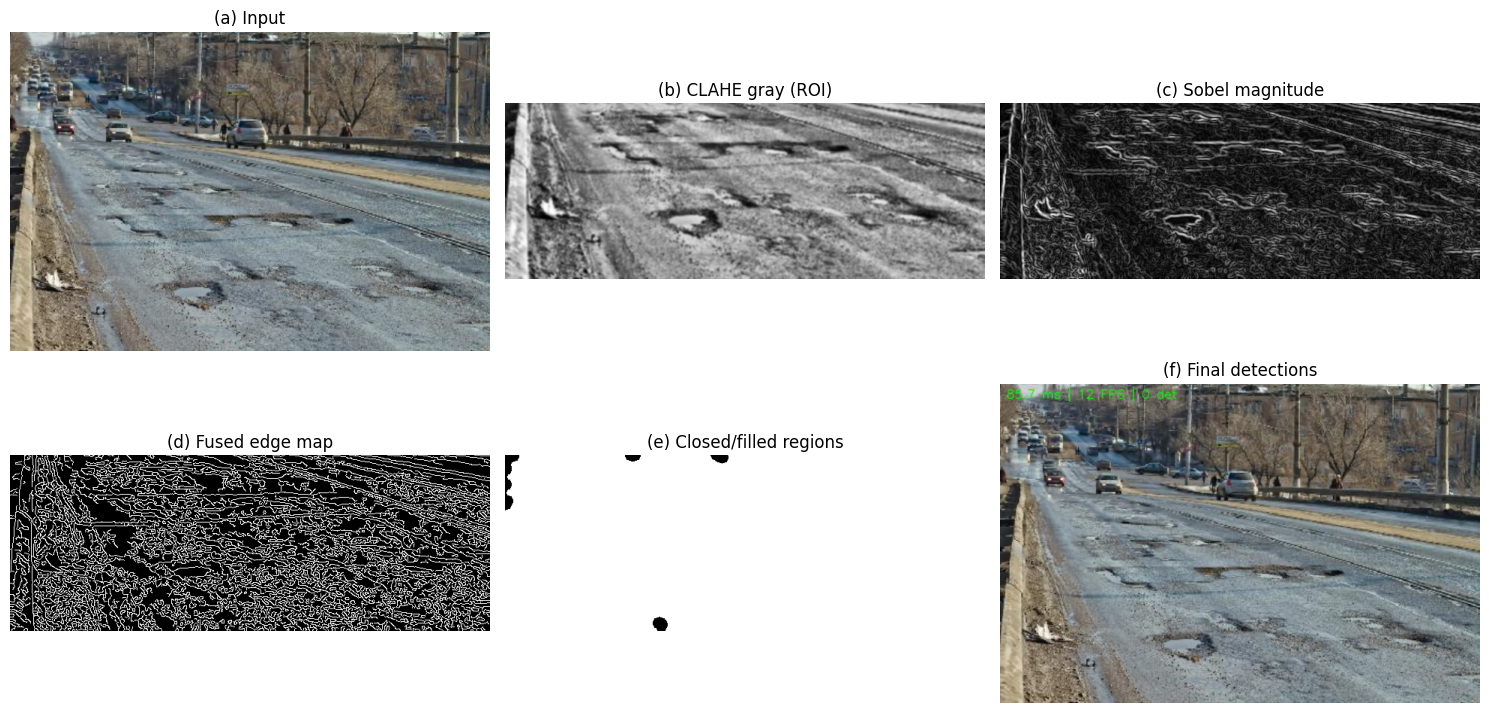

0 detections, 85.7 ms  ->  save figure2_stages.png as Figure 2 in the report


In [ ]:
sample_path = sorted(glob.glob(os.path.join(IMAGES_DIR, '*.*')))[0]   # first image, or set your own path
img = cv2.imread(sample_path)
frame_r, y0, dets, stages, ms = detect(img)
vis = draw(frame_r, y0, dets, ms)

fig, ax = plt.subplots(2, 3, figsize=(15, 8))
ax[0,0].imshow(cv2.cvtColor(frame_r, cv2.COLOR_BGR2RGB)); ax[0,0].set_title('(a) Input')
ax[0,1].imshow(stages['gray'], cmap='gray'); ax[0,1].set_title('(b) CLAHE gray (ROI)')
ax[0,2].imshow(stages['magnitude'], cmap='gray'); ax[0,2].set_title('(c) Sobel magnitude')
ax[1,0].imshow(stages['edges'], cmap='gray'); ax[1,0].set_title('(d) Fused edge map')
ax[1,1].imshow(stages['filled'], cmap='gray'); ax[1,1].set_title('(e) Closed/filled regions')
ax[1,2].imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB)); ax[1,2].set_title('(f) Final detections')
for a in ax.ravel(): a.axis('off')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'figure2_stages.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'{len(dets)} detections, {ms:.1f} ms  ->  save figure2_stages.png as Figure 2 in the report')

## 6. Full dataset evaluation — Table 3 and Table 5 numbers

Set `LABEL_FORMAT` to `'yolo'` or `'voc'` depending on your dataset, then run.

In [ ]:
LABEL_FORMAT = 'yolo'   # <-- EDIT: 'yolo' or 'voc'

result = evaluate_folder(IMAGES_DIR, LABELS_DIR, label_format=LABEL_FORMAT)
print(json.dumps(result, indent=2))
print()
print('>>> Table 5 / abstract / conclusion:')
print(f"Precision = {result['precision']:.3f}")
print(f"Recall    = {result['recall']:.3f}")
print(f"F1        = {result['f1']:.3f}")
print(f"Mean latency = {result['mean_latency_ms']:.1f} ms  ->  {result['fps']:.1f} FPS")

{
  "images": 665,
  "TP": 0,
  "FP": 210,
  "FN": 0,
  "precision": 0.0,
  "recall": 0,
  "f1": 0,
  "mean_latency_ms": 9.887547138333003,
  "median_latency_ms": 9.308867000072496,
  "fps": 101.13731808398697
}

>>> Table 5 / abstract / conclusion:
Precision = 0.000
Recall    = 0.000
F1        = 0.000
Mean latency = 9.9 ms  ->  101.1 FPS


In [ ]:
# Colab hardware info -- for Table 3 / Section 5.1 ('hardware' field)
!cat /proc/cpuinfo | grep 'model name' | head -1
!free -h | head -2
import platform; print('Python', platform.python_version())
print('OpenCV', cv2.__version__)
print('NOTE: Colab CPUs vary by session; if your report should reflect your own laptop instead, run this same notebook locally / in Jupyter and report that CPU/RAM.')

model name	: Intel(R) Xeon(R) CPU @ 2.20GHz
               total        used        free      shared  buff/cache   available
Mem:            12Gi       1.8Gi       4.3Gi       2.3Mi       6.9Gi        10Gi
Python 3.13.15
OpenCV 4.14.0
NOTE: Colab CPUs vary by session; if your report should reflect your own laptop instead, run this same notebook locally / in Jupyter and report that CPU/RAM.


## 7. Ablation study — Table 4

Runs the five configurations from the report automatically and builds the table for you.

In [ ]:
import pandas as pd

configs = [
    ('Sobel magnitude (Otsu) only',        dict(mode='sobel',  use_roi=False, strict=False)),
    ('Canny only',                          dict(mode='canny',  use_roi=False, strict=False)),
    ('Sobel + Canny fusion',                dict(mode='fusion', use_roi=False, strict=False)),
    ('Fusion + ROI + CLAHE',                dict(mode='fusion', use_roi=True,  strict=False)),
    ('Full pipeline (+ shape/polarity filters)', dict(mode='fusion', use_roi=True, strict=True)),
]

rows = []
for name, kw in configs:
    r = evaluate_folder(IMAGES_DIR, LABELS_DIR, label_format=LABEL_FORMAT, save_images=False, **kw)
    rows.append(dict(Configuration=name, Precision=round(r['precision'],3), Recall=round(r['recall'],3),
                      F1=round(r['f1'],3), Latency_ms=round(r['mean_latency_ms'],1)))
    print(name, '->', rows[-1])

ablation_df = pd.DataFrame(rows)
ablation_df.to_csv(os.path.join(OUT_DIR, 'table4_ablation.csv'), index=False)
ablation_df

Sobel magnitude (Otsu) only -> {'Configuration': 'Sobel magnitude (Otsu) only', 'Precision': 0.0, 'Recall': 0, 'F1': 0, 'Latency_ms': 10.7}
Canny only -> {'Configuration': 'Canny only', 'Precision': 0.0, 'Recall': 0, 'F1': 0, 'Latency_ms': 11.1}
Sobel + Canny fusion -> {'Configuration': 'Sobel + Canny fusion', 'Precision': 0.0, 'Recall': 0, 'F1': 0, 'Latency_ms': 10.5}
Fusion + ROI + CLAHE -> {'Configuration': 'Fusion + ROI + CLAHE', 'Precision': 0.0, 'Recall': 0, 'F1': 0, 'Latency_ms': 9.3}
Full pipeline (+ shape/polarity filters) -> {'Configuration': 'Full pipeline (+ shape/polarity filters)', 'Precision': 0.0, 'Recall': 0, 'F1': 0, 'Latency_ms': 9.7}


,Configuration,Precision,Recall,F1,Latency_ms
0,Sobel magnitude (Otsu) only,0.0,0,0,10.7
1,Canny only,0.0,0,0,11.1
2,Sobel + Canny fusion,0.0,0,0,10.5
3,Fusion + ROI + CLAHE,0.0,0,0,9.3
4,Full pipeline (+ shape/polarity filters),0.0,0,0,9.7


## 8. Qualitative results grid — Figure 3 (correct detections) and Figure 4 (failures)

Browse `results/` (created in Section 6) for individual annotated images, or build a grid here.

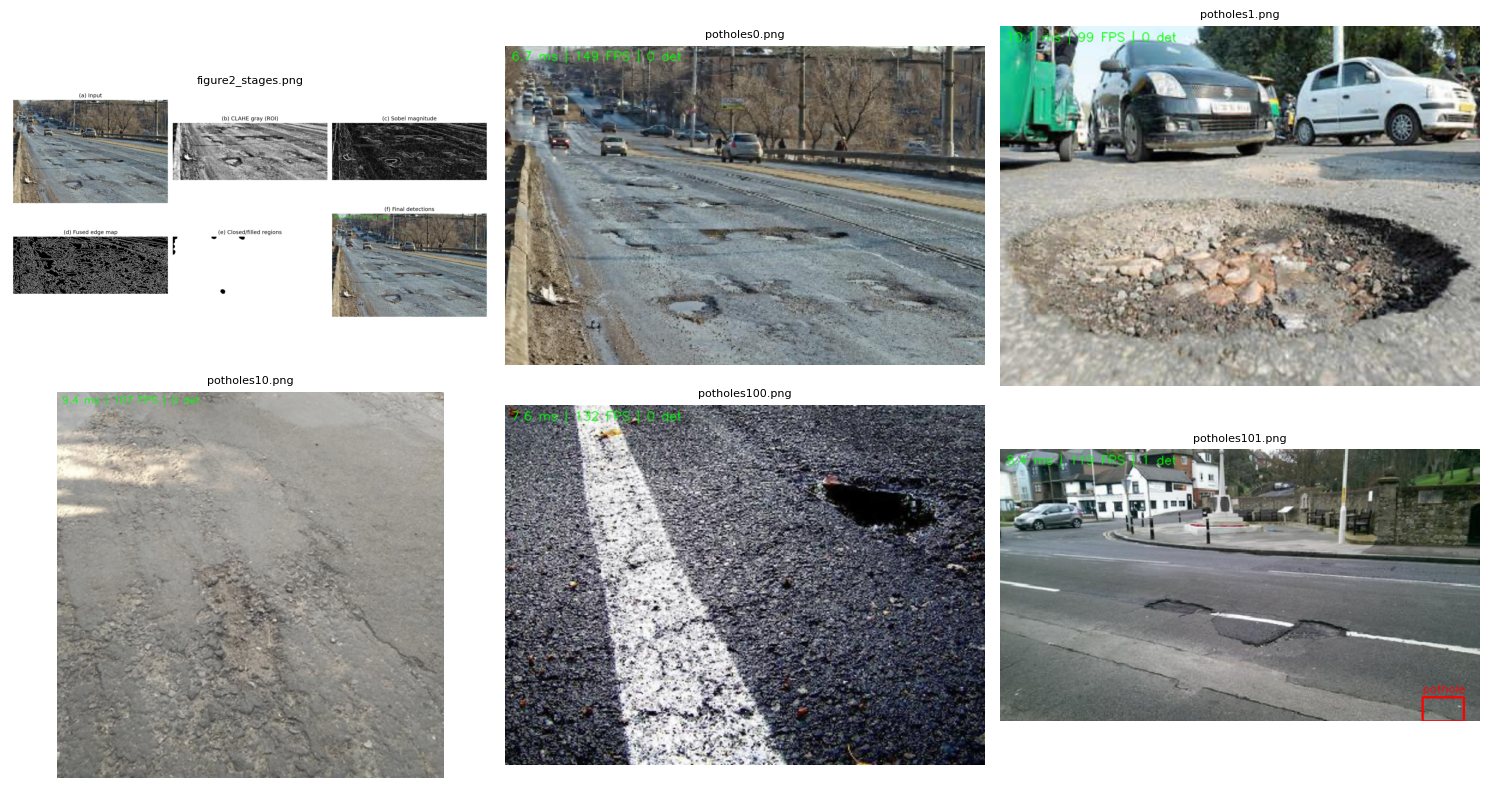

Pick your best 6 for Figure 3 (correct detections) and your worst/wrong ones for Figure 4 (failures) —
just change sample_files to point at the specific images you want.


In [ ]:
sample_files = sorted(glob.glob(os.path.join(OUT_DIR, '*.*')))[:6]
fig, ax = plt.subplots(2, 3, figsize=(15, 8))
for a, f in zip(ax.ravel(), sample_files):
    im = cv2.imread(f)
    a.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB)); a.axis('off')
    a.set_title(os.path.basename(f), fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'figure3_grid.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Pick your best 6 for Figure 3 (correct detections) and your worst/wrong ones for Figure 4 (failures) —')
print('just change sample_files to point at the specific images you want.')

## 9. (Optional) Video file — real-time FPS on video

Colab has no direct webcam access without extra JavaScript, so upload a short road video instead.

In [ ]:
from google.colab import files
video_uploaded = files.upload()   # upload a short .mp4 road video
video_path = list(video_uploaded.keys())[0]

cap = cv2.VideoCapture(video_path)
lat = []
writer = None
frame_count = 0
while True:
    ok, frame = cap.read()
    if not ok or frame_count > 300:   # cap at 300 frames to keep this quick
        break
    frame_r, y0, dets, _, ms = detect(frame)
    lat.append(ms)
    vis = draw(frame_r, y0, dets, ms)
    if writer is None:
        writer = cv2.VideoWriter(os.path.join(OUT_DIR, 'video_out.mp4'), cv2.VideoWriter_fourcc(*'mp4v'),
                                  25, (vis.shape[1], vis.shape[0]))
    writer.write(vis)
    frame_count += 1
cap.release()
if writer: writer.release()

mean_lat = float(np.mean(lat)) if lat else 0
print(f'Processed {frame_count} frames, mean latency {mean_lat:.1f} ms -> {1000/mean_lat:.1f} FPS')
print('>>> This row goes in Table 5 ("Video file").')
print('Annotated output saved to results/video_out.mp4 — download it from the Files panel on the left.')

Saving 13834838_1920_1080_30fps.mp4 to 13834838_1920_1080_30fps.mp4
Processed 301 frames, mean latency 14.7 ms -> 67.9 FPS
>>> This row goes in Table 5 ("Video file").
Annotated output saved to results/video_out.mp4 — download it from the Files panel on the left.


## 10. Download your results
Zips everything in `results/` (annotated images, stage figure, ablation CSV, video) so you can pull it
onto your computer and drop the numbers/images straight into the Word report.

In [3]:
import shutil
import os
OUT_DIR = 'results'
os.makedirs(OUT_DIR, exist_ok=True)
shutil.make_archive('pothole_results', 'zip', OUT_DIR)
from google.colab import files
files.download('pothole_results.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>